[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChrisW09/Python-for-AI-Driven-Automation/blob/main/15_capstones/48_capstone_ai_assistant.ipynb)

# 🏆 Notebook 48 — Capstone B: AI Customer-Feedback Assistant

> **Module:** Capstones · **Estimated time:** 90–120 min · **Difficulty:** Advanced · **Prerequisites:** Modules 1–13, especially NB 27–32 (AI engineering) and NB 45–46 (production).

The second capstone is the *engineering* twin of NB 47. Where NB 47 turned numerical data into a manager's PDF, this notebook turns *free-form text* into actionable structured output — and wraps the whole thing in the production discipline you learned in Module 13.

**Our running example.** One concrete artefact carries the entire notebook: an **overnight support inbox** of 50 raw customer messages — refund complaints, bug reports, feature wishes, praise — that has to be turned, by morning, into a PM-ready report. We build the machine that does it, station by station, and run that same inbox through it end to end. (These are the *words* behind the *numbers* you analysed in NB 47 — same support operation, the other half of the job.)

> 🧭 **Mental model: a factory assembly line for messages.** Picture each raw message as an unfinished part entering a factory. It moves down a conveyor belt through stations, and each station bolts on one thing: **Classify** stamps it (sentiment + topic), **Validate** is quality-control rejecting malformed parts, the **Rules engine** sorts parts into bins by urgency, **RAG** attaches the right instruction sheet from your manual, and the final station **packages** everything into a report and ships it. Two things run *alongside* the whole belt: a **trace log** (the factory's CCTV — every station records what it did) and an **eval gate** (the safety inspector who can shut the line down before a bad batch ships). Keep the assembly line in mind — every section below builds one station, and the architecture diagram is literally the belt.

**You're going to build an AI Customer-Feedback Assistant** that:

1. Ingests raw customer feedback (the kind a support inbox produces).
2. Classifies sentiment + topic with structured LLM output.
3. Routes high-priority items by combining the classification with a small rules engine.
4. Grounds answers in your *own* knowledge base via RAG.
5. Produces a daily report — runnable on a schedule, with cost tracking and an eval guard.

By the end you'll have ~250 lines of self-contained Python that demonstrate every AI-engineering pattern in the course. This is the artefact you point to in an interview when asked "what AI project have you built?".

## 🎯 What you will accomplish

1. Combine **prompting**, **RAG**, **validation**, **tracing**, and **scheduling** in one end-to-end pipeline.
2. Build a **golden eval set** and a **regression check** for the classifier.
3. Compute a **cost / latency / accuracy dashboard** from the trace log.
4. Write a 5-bullet **executive summary** of yesterday's feedback for a product manager.

## ✅ Prerequisites

Notebooks 1–46. Especially Modules 8 (AI engineering) and 13 (production).

## 📐 The architecture you'll implement

This diagram *is* the assembly line — read it top to bottom as a part travelling down the belt, station by station:

```
   ┌─────────────────────────────────────────────────────────────────┐
   │                                                                  │
   │   Raw feedback (DataFrame)                                       │
   │            │                                                     │
   │            ▼                                                     │
   │   ┌──────────────────┐    ┌──────────────────┐                  │
   │   │  Classify        │───►│  Validate (JSON  │                  │
   │   │  (LLM, JSON)     │    │  schema)         │                  │
   │   └──────────────────┘    └────────┬─────────┘                  │
   │                                     │                            │
   │            ┌────────────────────────┴──┐                         │
   │            ▼                            ▼                        │
   │   ┌────────────────┐         ┌──────────────────┐                │
   │   │ Rules engine   │         │  RAG: ground     │                │
   │   │ (priority)     │         │  answer in docs   │                │
   │   └───────┬────────┘         └────────┬─────────┘                │
   │           │                            │                          │
   │           └──────────────┬─────────────┘                         │
   │                          ▼                                       │
   │                ┌──────────────────────┐                          │
   │                │  Aggregate + report  │                          │
   │                └──────────────────────┘                          │
   │                          │                                       │
   │            ┌─────────────┴─────────────┐                         │
   │            ▼                            ▼                        │
   │   Daily executive summary       Cost / latency / eval trace      │
   │                                                                  │
   └─────────────────────────────────────────────────────────────────┘
```

## 1. Setup — the shared mock infrastructure

Before we build any stations, the factory needs power and a worker. The `MockLLM` below is our deterministic stand-in for a real chat model — it's the machine each station will call. Using a mock means the whole assembly line runs offline and produces the *same* output every time, which is exactly what you want while learning (and exactly what you want in tests).

In [1]:
import json
import re
import time
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from dataclasses import dataclass, asdict
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)


class MockLLM:
    """Deterministic offline mock; same contract as a real chat-completions API —
    the inline twin of llm_providers.MockLLM (NB 28), vendored so the capstone is
    self-contained."""
    POSITIVE = {"love", "great", "amazing", "excellent", "happy", "fantastic",
                "perfect", "delight", "smooth", "fast", "thank", "good"}
    NEGATIVE = {"hate", "terrible", "awful", "bad", "slow", "broken", "bug",
                "crash", "angry", "frustrating", "refund", "cancel", "worst"}
    BILLING  = {"refund", "invoice", "charge", "bill", "subscription", "renew", "payment", "price"}
    TECH     = {"error", "crash", "bug", "broken", "login", "password", "loading", "freeze", "stuck"}
    FEATURE  = {"feature", "request", "missing", "wish", "add", "support"}

    def _score(self, text, vocab):
        return sum(1 for w in re.findall(r"[a-z']+", text.lower()) if w in vocab)

    def chat(self, messages, model="mock-mini", temperature=0.0):
        sys_msg  = next((m["content"] for m in messages if m["role"] == "system"), "").lower()
        user_msg = [m["content"] for m in messages if m["role"] == "user"][-1]

        if "json" in sys_msg and ("sentiment" in sys_msg or "topic" in sys_msg):
            pos, neg = self._score(user_msg, self.POSITIVE), self._score(user_msg, self.NEGATIVE)
            sentiment = "positive" if pos > neg else "negative" if neg > pos else "neutral"
            scores = {"billing": self._score(user_msg, self.BILLING),
                      "tech":    self._score(user_msg, self.TECH),
                      "feature": self._score(user_msg, self.FEATURE)}
            topic = max(scores, key=scores.get) if max(scores.values()) > 0 else "other"
            out = json.dumps({"sentiment": sentiment, "topic": topic})
        elif "answer the user's question" in sys_msg or "qa" in sys_msg:
            # Echo a short context-based answer (mock)
            out = "Based on the provided context, " + user_msg.split("Question:")[-1].strip()[:120]
        else:
            out = "..."

        tokens_in  = sum(len(m["content"]) for m in messages) // 4
        tokens_out = len(out) // 4
        return {"text": out, "model": model,
                "tokens_in": tokens_in, "tokens_out": tokens_out,
                "latency_s": 0.001 + 0.0001 * tokens_out}


llm = MockLLM()
print("MockLLM ready ✅")


MockLLM ready ✅


> 🔌 **Using a real provider (OpenAI / Anthropic / Gemini / Ollama).**
> Every notebook in this module uses an offline `MockLLM` by default so you can run them without internet or API keys. Once you want real intelligence in the answers, swap one line — the unified interface in [`llm_providers.py`](../llm_providers.py) lets you use **OpenAI**, **Anthropic** (Claude), **Google** (Gemini), or a **local model via Ollama** without changing anything else.
> See the [LLM Providers Guide](../08_ai_engineering/A1_llm_providers_guide.ipynb) for the swap-in instructions, model recommendations, and cost estimates.


## 2. The data — incoming feedback and a small knowledge base

Now the raw parts arriving at the start of the belt: 50 overnight feedback messages, plus the factory's *instruction manual* — a small knowledge base the RAG station will pull from later. This is the same support operation from NB 47, but where that notebook had pre-aggregated numbers, here we start from the messy text those numbers were counted from.

In [2]:
# 50 fictional feedback messages (the kind a support inbox sees overnight)
FEEDBACK = [
    "Love the new dashboard! It's so much faster.",
    "The app crashed three times today, I'm so frustrated.",
    "Could you please add CSV export? I really need it for my reports.",
    "My invoice doesn't match my plan, please refund the difference of $45.",
    "Everything works fine, no complaints.",
    "Login is broken after the latest update.",
    "Fantastic support team — they resolved my issue in minutes. Thank you!",
    "Why is the renewal price so high? I'm considering cancelling.",
    "The new feature is great but loading is really slow on mobile.",
    "Please add Markdown support in the editor.",
    "Charged twice for my subscription last month.",
    "Dark mode would be amazing — please prioritise.",
    "500 error on file upload. Help.",
    "Smooth experience overall, would recommend.",
    "Fantastic update — keep up the good work!",
    "I'm cancelling, this is unusable.",
    "Password reset email never arrives.",
    "Bill is wrong again, third time this quarter.",
    "Great product. Five stars.",
    "Mobile app freezes whenever I try to upload images.",
    "Refund requested last week — still no update.",
    "Could you support SSO with Okta?",
    "Latest patch broke the export feature.",
    "Pricing page is confusing.",
    "Loving the new automations!",
    "Stuck at the loading screen, can't access my data.",
    "Add an Indonesian translation please.",
    "Charged for a plan I never signed up to.",
    "Wonderful UI, very intuitive.",
    "Crash on Windows 11, every time.",
    "Customer service was rude on the phone.",
    "I want a full refund. This is unacceptable.",
    "The API documentation is excellent, thank you.",
    "How do I cancel? The button is hidden.",
    "Cool new dashboard! Lovely details.",
    "Can you add a CSV export for the analytics page?",
    "The mobile version is unusable lately.",
    "Got billed twice, please fix.",
    "Slack integration would be a game changer.",
    "Found a major security issue, contacting you privately.",
    "Smooth as silk, the new release works perfectly.",
    "The webhook endpoint returns 500 randomly.",
    "Annual discount doesn't apply on my account.",
    "Love the speed improvements. Top job!",
    "Cancellation page is confusing.",
    "Could you support a Zapier integration?",
    "Login keeps logging me out after 5 minutes.",
    "Pricing is too high for what we get.",
    "Excellent customer service, would recommend.",
    "The new mobile app is much better.",
]
print(f"Loaded {len(FEEDBACK)} feedback messages.")


Loaded 50 feedback messages.


In [3]:
# Knowledge base — answers to common questions, used in the RAG step
KB = [
    ("billing.refunds",
     "Refunds are issued within 5 business days. Request from the Billing page within 30 days of purchase."),
    ("billing.subscriptions",
     "Subscriptions renew automatically. Cancel from Settings → Billing → Cancel subscription. You retain access until period end."),
    ("billing.pricing",
     "Three tiers: Free, Pro $19/mo, Enterprise on request. Annual billing gives a 15% discount."),
    ("tech.password",
     "Use 'Forgot password' on the sign-in page. Reset emails arrive within 5 minutes; check spam."),
    ("tech.errors",
     "A 500 error usually indicates a temporary backend issue. Wait 60 seconds and retry. Contact support with the trace ID if persistent."),
    ("feature.exports",
     "CSV and JSON exports are on Pro plans. XLSX is on the roadmap."),
    ("feature.integrations",
     "Slack, Microsoft Teams, and Zapier are supported. Okta SSO is Enterprise-only."),
]
print(f"Knowledge base: {len(KB)} documents.")


Knowledge base: 7 documents.


## 3. Step 1 of the pipeline — classify with structured output

**Station 1: the stamping press.** Every part comes in as shapeless prose; the first station stamps two machine-readable labels on it — `sentiment` and `topic` — as strict JSON. Structured output is what lets all the *downstream* stations act automatically: a rules engine can't branch on a paragraph, but it can branch on `{"sentiment": "negative", "topic": "billing"}`.

In [4]:
CLASSIFY_SYSTEM = (
    "You analyse customer messages. "
    "Return JSON with keys 'sentiment' (positive/neutral/negative) and "
    "'topic' (billing/tech/feature/other). Reply with the JSON only."
)

def classify(text: str) -> dict:
    """Run a single feedback through the classifier; return a typed dict."""
    r = llm.chat(messages=[
        {"role": "system", "content": CLASSIFY_SYSTEM},
        {"role": "user",   "content": text},
    ])
    try:
        labels = json.loads(r["text"])
    except json.JSONDecodeError:
        labels = {"sentiment": "unknown", "topic": "unknown"}
    return {
        "sentiment":  labels.get("sentiment", "unknown"),
        "topic":      labels.get("topic", "unknown"),
        "tokens_in":  r["tokens_in"],
        "tokens_out": r["tokens_out"],
        "latency_s":  r["latency_s"],
    }


# Quick test
print(classify("My invoice is wrong, please refund."))


{'sentiment': 'negative', 'topic': 'billing', 'tokens_in': 48, 'tokens_out': 11, 'latency_s': 0.0021000000000000003}


## 4. Step 2 — validate the structured output

**Station 2: quality control.** No factory ships a part straight off the press without inspecting it. The model is fast but not infallible — it can emit a typo'd label or malformed JSON. This station rejects anything that doesn't match the allowed values *before* it reaches a station that would choke on it. Always validate before pushing data downstream.

In [5]:
VALID_SENTIMENTS = {"positive", "neutral", "negative"}
VALID_TOPICS     = {"billing", "tech", "feature", "other"}

def validate(record: dict) -> list[str]:
    errs = []
    if record.get("sentiment") not in VALID_SENTIMENTS:
        errs.append(f"bad sentiment: {record.get('sentiment')!r}")
    if record.get("topic") not in VALID_TOPICS:
        errs.append(f"bad topic: {record.get('topic')!r}")
    return errs


# Test
print(validate({"sentiment": "positive", "topic": "feature"}))         # []
print(validate({"sentiment": "happy",    "topic": "tech"}))            # ["bad sentiment: 'happy'"]


[]
["bad sentiment: 'happy'"]


## 5. Step 3 — the priority rules engine

**Station 3: the sorting bins.** Now that each part carries clean labels, this station drops it into an urgency bin — escalate now, handle today, route to product, or just acknowledge. Crucially, this is *plain `if`-statements, not the model*: business rules belong in code you can review, test, and audit — never buried in a prompt that quietly drifts. Keep it separate from the model so it's testable on its own.

In [6]:
def priority(text: str, sentiment: str, topic: str, is_vip: bool = False) -> str:
    """Return one of: 'p0_escalate', 'p1_negative', 'p2_route', 'p3_acknowledge'."""
    lower = text.lower()
    if any(w in lower for w in ("urgent", "security", "lawyer", "escalate", "asap")):
        return "p0_escalate"
    if is_vip and sentiment == "negative":
        return "p0_escalate"
    if sentiment == "negative" and topic in {"billing", "tech"}:
        return "p1_negative"
    if topic == "feature":
        return "p2_route"          # collect for the product team
    return "p3_acknowledge"


# Test priorities
for txt in [
    "My invoice is wrong, please refund.",
    "Add a Zapier integration please.",
    "Found a security issue, contacting privately.",
    "Love the new dashboard.",
]:
    cls = classify(txt)
    print(f"{priority(txt, cls['sentiment'], cls['topic']):<16}  ← {txt!r}")


p1_negative       ← 'My invoice is wrong, please refund.'
p2_route          ← 'Add a Zapier integration please.'
p0_escalate       ← 'Found a security issue, contacting privately.'
p3_acknowledge    ← 'Love the new dashboard.'


## 6. Step 4 — RAG for actually answering the question

**Station 4: the instruction-sheet attacher.** A sorted part is good; a sorted part *with the right answer attached* is shippable. For items that ask a concrete question — how do I get a refund, why won't my password reset, do you support Okta — this station pulls the matching page from the knowledge base (§2's instruction manual) and grounds the model's answer in it, so the assistant cites *your* docs instead of inventing an answer.

In [7]:
def keyword_score(query, doc_text):
    q = set(re.findall(r"[a-z']+", query.lower()))
    d = set(re.findall(r"[a-z']+", doc_text.lower()))
    return len(q & d)

def retrieve(query, k=2):
    scored = sorted([(keyword_score(query, t), n, t) for n, t in KB], reverse=True)
    return [(n, t) for s, n, t in scored[:k] if s > 0]

def rag_answer(question: str) -> dict:
    snippets = retrieve(question, k=2)
    if not snippets:
        return {"answer": None, "sources": [], "tokens_in": 0, "tokens_out": 0, "latency_s": 0}
    context = "\n\n".join(f"[{n}] {t}" for n, t in snippets)
    r = llm.chat(messages=[
        {"role": "system", "content":
            "Answer the user's question using ONLY the context provided. If the context does not contain the answer, say so."},
        {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {question}"},
    ])
    return {"answer": r["text"], "sources": [n for n, _ in snippets],
            "tokens_in": r["tokens_in"], "tokens_out": r["tokens_out"],
            "latency_s": r["latency_s"]}


# Quick test
result = rag_answer("How do I cancel my subscription?")
print("Answer :", result["answer"])
print("Sources:", result["sources"])


Answer : Based on the provided context, How do I cancel my subscription?
Sources: ['billing.subscriptions']


## 7. Step 5 — the full pipeline + tracing

**Switch on the conveyor belt.** So far we've built each station in isolation; now we connect them and run all 50 parts down the line in one pass. And we turn on the factory CCTV: every part records its own row of trace data — labels, priority, tokens, latency — so we can later debug, evaluate, and report cost. No trace, no observability; with it, every decision the line made is auditable after the fact.

In [8]:
@dataclass
class Outcome:
    request_id:  str
    text:        str
    sentiment:   str
    topic:       str
    priority:    str
    rag_answer:  str | None
    sources:     list
    tokens_in:   int
    tokens_out:  int
    latency_s:   float
    validation_errors: list


def run_pipeline(feedback: list[str], is_vip_fn=lambda t: False) -> list[Outcome]:
    """Process every message end-to-end and return a list of typed outcomes."""
    outcomes = []
    for text in feedback:
        request_id = hashlib.sha1(f"{time.time()}::{text}".encode()).hexdigest()[:10]

        # 1) Classify
        cls = classify(text)
        errs = validate(cls)

        # 2) Priority
        prio = priority(text, cls["sentiment"], cls["topic"], is_vip=is_vip_fn(text))

        # 3) RAG only for p1/p2/p3 (skip p0 — escalation goes to a human anyway)
        rag = {"answer": None, "sources": [], "tokens_in": 0, "tokens_out": 0, "latency_s": 0}
        if prio in {"p1_negative", "p2_route", "p3_acknowledge"} and not errs:
            rag = rag_answer(text)

        outcomes.append(Outcome(
            request_id=request_id, text=text,
            sentiment=cls["sentiment"], topic=cls["topic"], priority=prio,
            rag_answer=rag["answer"], sources=rag["sources"],
            tokens_in =cls["tokens_in"]  + rag["tokens_in"],
            tokens_out=cls["tokens_out"] + rag["tokens_out"],
            latency_s =cls["latency_s"]  + rag["latency_s"],
            validation_errors=errs,
        ))
    return outcomes


outcomes = run_pipeline(FEEDBACK)
trace_df = pd.DataFrame([asdict(o) for o in outcomes])
print(f"Processed {len(trace_df)} messages.")
print(trace_df[["sentiment", "topic", "priority", "tokens_in", "tokens_out"]].head(8))


Processed 50 messages.
  sentiment    topic        priority  tokens_in  tokens_out
0  positive    other  p3_acknowledge        159          28
1   neutral    other  p3_acknowledge        163          31
2   neutral  feature        p2_route        162          35
3  negative  billing     p1_negative        164          36
4   neutral    other  p3_acknowledge         49          10
5  negative     tech     p1_negative        140          27
6  positive  feature        p2_route        171          36
7   neutral  billing  p3_acknowledge        150          34


## 8. The KPI dashboard

The CCTV footage from §7 is only useful if someone watches it. This section reads the trace log back and turns it into the numbers a factory manager checks every morning: how many parts of each priority, what did the run cost, how fast was it, where's the sentiment landing. This is reading the line's own telemetry.

In [9]:
# Some quick numbers
n = len(trace_df)
priority_counts  = trace_df["priority"].value_counts().reindex(
    ["p0_escalate","p1_negative","p2_route","p3_acknowledge"], fill_value=0)
sentiment_counts = trace_df["sentiment"].value_counts()
topic_counts     = trace_df["topic"].value_counts()

# Costs (using a typical input/output rate)
PRICE_IN_PER_1K  = 0.0006
PRICE_OUT_PER_1K = 0.0024
trace_df["cost_usd"] = (trace_df["tokens_in"]  / 1000 * PRICE_IN_PER_1K +
                        trace_df["tokens_out"] / 1000 * PRICE_OUT_PER_1K)

print(f"📊 AI Feedback Assistant — Run Summary")
print("-" * 60)
print(f"Messages processed : {n}")
print(f"Validation errors  : {(trace_df['validation_errors'].str.len() > 0).sum()}")
print(f"Total cost         : ${trace_df['cost_usd'].sum():.4f}")
print(f"Mean cost / msg    : ${trace_df['cost_usd'].mean():.5f}")
print(f"Mean latency       : {trace_df['latency_s'].mean()*1000:.1f} ms")
print(f"p95 latency        : {trace_df['latency_s'].quantile(0.95)*1000:.1f} ms")
print("\nPriority mix:")
for p, c in priority_counts.items():
    print(f"  {p:<18}: {c:>3}  ({c/n:.0%})")
print("\nSentiment mix:")
for s, c in sentiment_counts.items():
    print(f"  {s:<10}: {c:>3}  ({c/n:.0%})")
print("\nTopic mix:")
for t, c in topic_counts.items():
    print(f"  {t:<10}: {c:>3}  ({c/n:.0%})")


📊 AI Feedback Assistant — Run Summary
------------------------------------------------------------
Messages processed : 50
Validation errors  : 0
Total cost         : $0.0066
Mean cost / msg    : $0.00013
Mean latency       : 4.2 ms
p95 latency        : 5.5 ms

Priority mix:
  p0_escalate       :   1  (2%)
  p1_negative       :   5  (10%)
  p2_route          :   8  (16%)
  p3_acknowledge    :  36  (72%)

Sentiment mix:
  neutral   :  34  (68%)
  positive  :  10  (20%)
  negative  :   6  (12%)

Topic mix:
  other     :  29  (58%)
  feature   :   8  (16%)
  tech      :   7  (14%)
  billing   :   6  (12%)


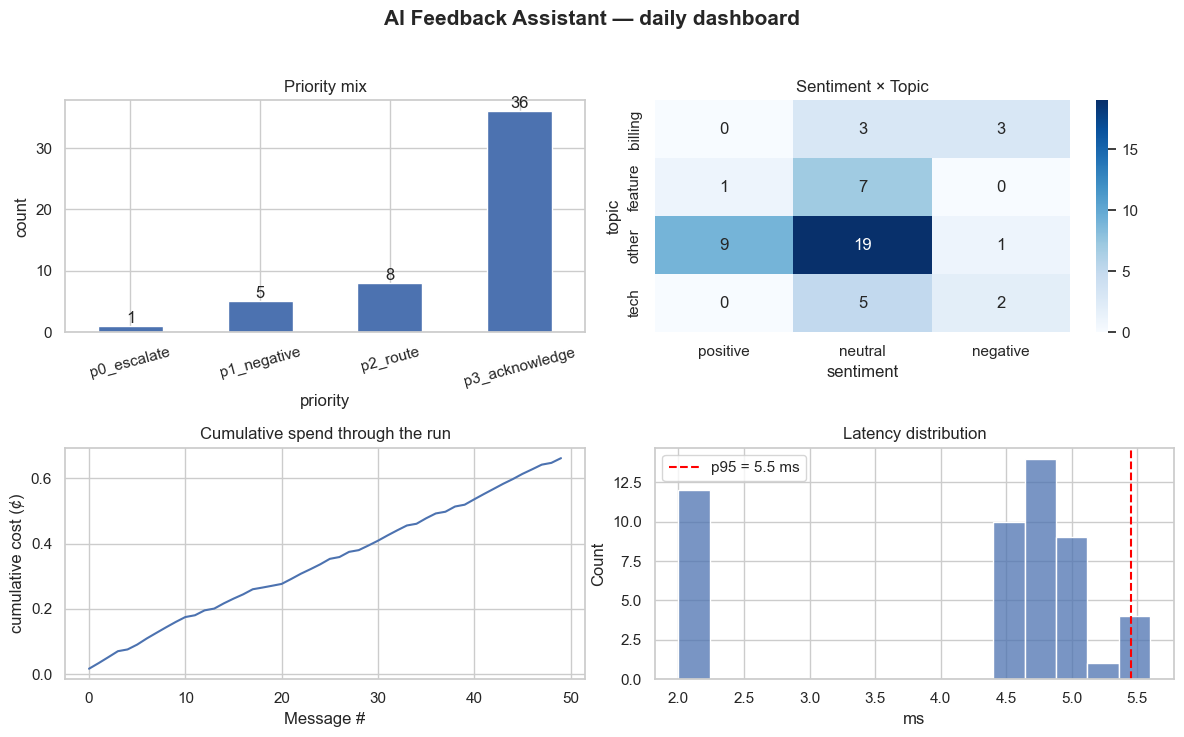

In [10]:
# Visual dashboard — four panels: one layout line, then one-liners per panel
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
fig.suptitle("AI Feedback Assistant — daily dashboard", fontsize=15, fontweight="bold")

# (0,0) Priority mix
priority_counts.plot(kind="bar", ax=axes[0, 0], title="Priority mix", ylabel="count", rot=15)
axes[0, 0].bar_label(axes[0, 0].containers[0])

# (0,1) Sentiment × Topic heatmap
cross = pd.crosstab(trace_df["topic"], trace_df["sentiment"]).reindex(
    columns=["positive", "neutral", "negative"], fill_value=0)
sns.heatmap(cross, annot=True, fmt="d", cmap="Blues", ax=axes[0, 1])
axes[0, 1].set_title("Sentiment × Topic")

# (1,0) Cumulative cost
(trace_df["cost_usd"].cumsum() * 100).reset_index(drop=True).plot(
    ax=axes[1, 0], title="Cumulative spend through the run",
    xlabel="Message #", ylabel="cumulative cost (¢)")

# (1,1) Latency distribution with the p95 marked
sns.histplot(trace_df["latency_s"] * 1000, bins=15, ax=axes[1, 1])
p95 = trace_df["latency_s"].quantile(0.95) * 1000
axes[1, 1].axvline(p95, color="red", ls="--", label=f"p95 = {p95:.1f} ms")
axes[1, 1].set(title="Latency distribution", xlabel="ms")
axes[1, 1].legend()

fig.tight_layout(rect=[0, 0, 1, 0.96]);

## 9. The executive summary — what a PM actually wants to read

**The final packing station.** Everything upstream exists to produce *this* — the one thing that leaves the factory and lands on a human's desk. The dashboard is for engineers; the PM wants a paragraph they can act on before their coffee's cold. The artefact of this whole pipeline isn't the dashboard. It's a short summary in language a manager can act on.

In [11]:
def write_executive_summary(trace_df: pd.DataFrame) -> str:
    n = len(trace_df)
    p0 = (trace_df["priority"] == "p0_escalate").sum()
    p1 = (trace_df["priority"] == "p1_negative").sum()
    neg_billing = ((trace_df["sentiment"] == "negative") &
                   (trace_df["topic"] == "billing")).sum()
    top_topic = trace_df["topic"].value_counts().idxmax()
    pos_rate  = (trace_df["sentiment"] == "positive").mean()

    bullets = [
        f"📊 Processed {n} messages overnight at ${trace_df['cost_usd'].sum():.4f} total LLM spend.",
        f"🚨 {p0} P0 escalations require human review immediately.",
        f"⚠️  {p1} negative-sentiment messages flagged in billing/tech for first-response.",
        f"💸 {neg_billing} billing-related complaints — investigate any refund-process spike.",
        f"📈 Positive feedback rate: {pos_rate:.0%}.  Top topic: '{top_topic}'.",
    ]
    return "\n".join(bullets)


summary = write_executive_summary(trace_df)
print(summary)


📊 Processed 50 messages overnight at $0.0066 total LLM spend.
🚨 1 P0 escalations require human review immediately.
⚠️  5 negative-sentiment messages flagged in billing/tech for first-response.
💸 3 billing-related complaints — investigate any refund-process spike.
📈 Positive feedback rate: 20%.  Top topic: 'other'.


## 10. The regression check — would tomorrow's prompt change still pass?

**The safety inspector.** A factory line is only as trustworthy as its inspection regime. The stations all work *today* — but the moment someone edits the classify prompt, the line could start mis-stamping parts and nobody would notice until the bad batch reached customers. So before any prompt edit ships, we re-run the eval against a golden set. If the new prompt regresses, the inspector pulls the cord and the deploy fails.

In [12]:
# Same golden set you'd build for an AI feature (matches what NB 27 demonstrated)
GOLDEN = [
    ("I love this feature, please add dark mode.",                       "positive", "feature"),
    ("The login is broken and throws an error.",                        "negative", "tech"),
    ("Could you add a CSV export feature?",                             "neutral",  "feature"),
    ("Please refund my invoice, the charge is wrong.",                  "negative", "billing"),
    ("This bug is awful.",                                              "negative", "tech"),
    ("Fantastic work, thank you so much!",                              "positive", "other"),
    ("The price is too high and the subscription feels like a bad deal.", "negative", "billing"),
]

def run_golden_eval(prompt: str) -> pd.DataFrame:
    """Measure only — score the prompt against the golden set, no verdict.
    Keeping measurement separate from the ship/halt decision means the same
    numbers can feed a printout, a chart, and a CI job without re-running."""
    rows = []
    for text, gold_s, gold_t in GOLDEN:
        r = llm.chat(messages=[
            {"role": "system", "content": prompt},
            {"role": "user",   "content": text},
        ])
        try:
            pred = json.loads(r["text"])
        except json.JSONDecodeError:
            pred = {"sentiment": "unknown", "topic": "unknown"}
        rows.append({
            "text":      text[:38] + ("…" if len(text) > 38 else ""),
            "gold":      f"{gold_s}/{gold_t}",
            "predicted": f"{pred.get('sentiment', '?')}/{pred.get('topic', '?')}",
            "ok":        pred.get("sentiment") == gold_s and pred.get("topic") == gold_t,
        })
    return pd.DataFrame(rows)


def regression_check(prompt: str, baseline_acc: float, tolerance: float = 0.10) -> bool:
    """Decide only — turn the measurement into a ship/halt verdict."""
    res = run_golden_eval(prompt)
    acc = res["ok"].mean()
    print(f"Eval accuracy: {acc:.0%}  (baseline {baseline_acc:.0%}, tolerance {tolerance:.0%})")
    if acc < baseline_acc - tolerance:
        print("❌ Regression — refusing to ship this prompt.")
        return False
    print("✅ Eval passed.")
    return True


# The shipping policy, written once: never fall more than `TOLERANCE` below
# the accuracy we already trust. Both the gate and the chart in §10.1 read
# these, so the picture can never disagree with the check it is drawing.
BASELINE, TOLERANCE = 0.70, 0.10

regression_check(CLASSIFY_SYSTEM, baseline_acc=BASELINE, tolerance=TOLERANCE)

Eval accuracy: 100%  (baseline 70%, tolerance 10%)
✅ Eval passed.


True

### 10.1 The gate, drawn

`✅ Eval passed` is a verdict with no context — it hides *how close* you came to the cord. A **bullet chart** is the right form for exactly this shape of question (one measure, one target, a few qualitative zones): the pale bands are the policy, the vertical tick is the baseline you must not fall below, and the dark bar is where today's prompt actually landed. One glance tells you whether you shipped with room to spare or squeaked through.

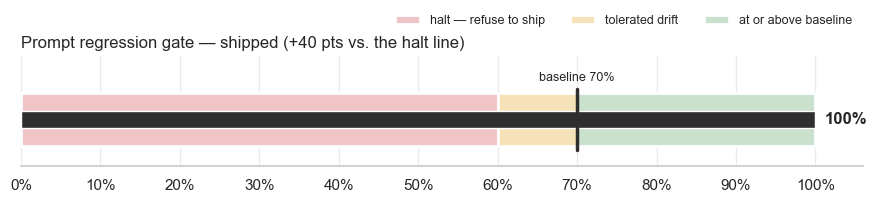

                                   text             gold        predicted   ok
I love this feature, please add dark m… positive/feature positive/feature True
The login is broken and throws an erro…    negative/tech    negative/tech True
    Could you add a CSV export feature?  neutral/feature  neutral/feature True
Please refund my invoice, the charge i… negative/billing negative/billing True
                     This bug is awful.    negative/tech    negative/tech True
     Fantastic work, thank you so much!   positive/other   positive/other True
The price is too high and the subscrip… negative/billing negative/billing True


In [13]:
# BASELINE and TOLERANCE come from §10 — same policy, same numbers.
detail = run_golden_eval(CLASSIFY_SYSTEM)
acc    = detail["ok"].mean()

# Qualitative bands: the shipping policy, drawn once so it can be read, not recited.
bands = [(0.0,                  BASELINE - TOLERANCE, "#F0C5C7", "halt — refuse to ship"),
         (BASELINE - TOLERANCE, BASELINE,             "#F6E2B8", "tolerated drift"),
         (BASELINE,             1.0,                  "#C9E1CD", "at or above baseline")]

fig, ax = plt.subplots(figsize=(9, 2.3))
for lo, hi, colour, label in bands:
    ax.barh(0, hi - lo, left=lo, height=0.62, color=colour,
            edgecolor="white", linewidth=2, label=label)

ax.barh(0, acc, height=0.20, color="#2f2f2f", zorder=3)              # the measure
ax.plot([BASELINE] * 2, [-0.36, 0.36], color="#2f2f2f", lw=2.5, zorder=4)
ax.text(BASELINE, 0.42, f"baseline {BASELINE:.0%}", ha="center", va="bottom", fontsize=9)
ax.text(acc + 0.012, 0, f"{acc:.0%}", va="center", fontsize=12, fontweight="bold", zorder=5)

verdict = "shipped" if acc >= BASELINE - TOLERANCE else "halted"
ax.set_title(f"Prompt regression gate — {verdict} "
             f"({(acc - (BASELINE - TOLERANCE)) * 100:+.0f} pts vs. the halt line)", loc="left")
ax.set_xlim(0, 1.06); ax.set_ylim(-0.55, 0.75)
ax.set_xticks(np.arange(0, 1.01, 0.1))
ax.set_xticklabels([f"{t:.0%}" for t in np.arange(0, 1.01, 0.1)])
ax.set_yticks([])
ax.grid(False); ax.grid(True, axis="x", alpha=0.4)
ax.legend(loc="lower right", bbox_to_anchor=(1, 1.16), ncols=3, frameon=False, fontsize=9)
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

# The per-case detail belongs in a table, not in the chart — seven rows of text
# is something you read, not something you look at.
print(detail.to_string(index=False))

> 🔬 **What the picture says.** The mock lands well clear of the halt line, so the bar sits deep in the green band — but the picture is worth keeping precisely for the day it doesn't. When a prompt edit drags the bar into the amber, you can see at a glance that you are *drifting* rather than *failing*, which is the difference between "keep an eye on it" and "revert now". The per-case table underneath is the other half: an aggregate of seven cases can hide which one broke, and the row that flips is usually the one that tells you what the prompt edit actually did.

## 11. Wiring it all together — a single scheduled task

**The whole factory, behind one switch.** This is the payoff: every station, the CCTV, and the safety inspector wrapped into a single function a scheduler can flip on each night — exactly the night-shift robot from NB 46, now running an *AI* line. It produces the daily report file, the cost dashboard, and emits the executive summary to (mock) Slack — all unattended.

In [14]:
def daily_run(feedback: list[str], baseline_acc: float = 0.65) -> dict:
    """
    The full nightly task. Returns a status dict for the scheduler to log.
    """
    # 1) Regression guard — never ship a bad prompt
    if not regression_check(CLASSIFY_SYSTEM, baseline_acc):
        return {"status": "halted", "reason": "prompt regression"}

    # 2) Process the inbox
    outcomes = run_pipeline(feedback)
    trace_df = pd.DataFrame([asdict(o) for o in outcomes])

    # 3) Compute cost
    PRICE_IN_PER_1K, PRICE_OUT_PER_1K = 0.0006, 0.0024
    trace_df["cost_usd"] = (trace_df["tokens_in"]  / 1000 * PRICE_IN_PER_1K +
                            trace_df["tokens_out"] / 1000 * PRICE_OUT_PER_1K)

    # 4) Save the trace and the report
    out_dir = Path("/tmp/feedback_reports")
    out_dir.mkdir(exist_ok=True)
    trace_df.to_csv(out_dir / "trace.csv", index=False)
    summary = write_executive_summary(trace_df)
    (out_dir / "summary.txt").write_text(summary)

    # 5) Mock-send Slack
    print(f"\n[mock Slack send] daily-summary channel:\n{summary}\n")

    return {
        "status":           "ok",
        "n_messages":       len(trace_df),
        "cost_usd":         round(trace_df["cost_usd"].sum(), 5),
        "p0_escalations":   int((trace_df["priority"] == "p0_escalate").sum()),
        "report_dir":       str(out_dir),
    }


result = daily_run(FEEDBACK)
print(f"\nResult: {result}")


Eval accuracy: 100%  (baseline 65%, tolerance 10%)
✅ Eval passed.

[mock Slack send] daily-summary channel:
📊 Processed 50 messages overnight at $0.0066 total LLM spend.
🚨 1 P0 escalations require human review immediately.
⚠️  5 negative-sentiment messages flagged in billing/tech for first-response.
💸 3 billing-related complaints — investigate any refund-process spike.
📈 Positive feedback rate: 20%.  Top topic: 'other'.


Result: {'status': 'ok', 'n_messages': 50, 'cost_usd': np.float64(0.00662), 'p0_escalations': 1, 'report_dir': '/tmp/feedback_reports'}


**Read what just happened.** In a single function, you:

- Guarded against shipping a regressed prompt (the eval gate).
- Classified, validated, and routed 50 free-form customer messages.
- Computed cost, latency, and accuracy for the run.
- Saved a trace to disk that any later debugging session can read.
- Produced a five-bullet executive summary you'd actually send to a PM.

This is the *engineering* version of a capstone. Schedule it nightly (NB 46), wrap it in a package (NB 45), and you've shipped real production AI.

## 🧪 Bonus exercises

### Exercise 1 — Add an English-only filter

The pipeline currently processes every message. Add a step that detects when a message is *not in English* and routes it to `p2_route` regardless of priority. Use a tiny rule: if more than 30% of characters aren't ASCII letters/spaces/punctuation, treat as non-English.

In [15]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
import string
def is_likely_english(text: str) -> bool:
    allowed = set(string.ascii_letters + string.digits + string.whitespace + string.punctuation)
    ratio = sum(c in allowed for c in text) / max(1, len(text))
    return ratio >= 0.7

# Hook it into run_pipeline by checking after classify and overriding priority:
#   if not is_likely_english(text): prio = "p2_route"
print(is_likely_english("Hello, how are you?"))   # True
print(is_likely_english("こんにちは、元気ですか？"))   # False
```

In production you'd use a real language-detection library (`langdetect`, `langid`, or an LLM call). The ASCII heuristic catches most cases for free.
</details>

### Exercise 2 — Add VIP-customer routing

Add a `vip_customers` set (a small list of customer IDs or email patterns). When their feedback comes in, *any* negative sentiment should escalate to p0. Demonstrate it by adding `is_vip_fn=lambda t: "VIP" in t` to `daily_run`.

In [16]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def is_vip(text: str) -> bool:
    return "[VIP]" in text or "vip-customer" in text.lower()

# Then call:
outcomes_vip = run_pipeline(FEEDBACK, is_vip_fn=is_vip)
```

Try inserting `"[VIP] My invoice is wrong."` into `FEEDBACK` and verify it's routed to `p0_escalate` even though the rule for non-VIPs would mark it `p1_negative`.

In production the VIP list lives in your CRM and is loaded as configuration — never hard-coded.
</details>

### Exercise 3 — Bake the daily summary into a markdown report

Modify `daily_run` to also emit a `report.md` with:

- The summary
- A markdown table of the priority/sentiment/topic crosstabs
- A link to the saved trace.csv

This is what you'd commit to a `reports/` folder, or email as an attachment.

In [17]:
# Your code here  👇


<details>
<summary>💡 <b>Solution</b></summary>

```python
def render_markdown_report(trace_df: pd.DataFrame, out_dir: Path) -> Path:
    summary = write_executive_summary(trace_df)
    sentiment_crosstab = pd.crosstab(trace_df["topic"], trace_df["sentiment"]).to_markdown()
    priority_summary   = trace_df["priority"].value_counts().to_markdown()

    md = f"""# AI Feedback Assistant — Daily Report

## Executive summary

{summary}

## Priority mix

{priority_summary}

## Topic × Sentiment

{sentiment_crosstab}

## Raw trace

See [trace.csv]({out_dir}/trace.csv) for every message processed.
"""
    out_dir.mkdir(parents=True, exist_ok=True)   # ensure the directory exists
    path = out_dir / "report.md"
    path.write_text(md)
    return path


path = render_markdown_report(trace_df, Path("/tmp/feedback_reports"))
print(f"Wrote {path}")
print((path).read_text()[:600])
```

The pattern — *trace.csv for engineers, report.md for managers* — is the single most useful artefact split in production data pipelines. Engineers debug from the CSV; managers act on the Markdown.
</details>

## 🧠 Stretch exercises

Two more applied exercises to deepen the material. Try them yourself before opening the solution.


### Stretch exercise A — Daily cost cap

Add a `daily_cost_cap_usd` parameter to `daily_run`. If the total cost would exceed the cap, halt processing and emit a 'cost cap exceeded' Slack alert. Verify with a cap of $0.001.


<details>
<summary>💡 <b>Solution</b></summary>

```python
def send_slack_alert(msg: str):       # offline stub — wire to a real Slack webhook in production
    print(f"[SLACK] {msg}")

def daily_run_capped(feedback, baseline_acc=0.50, cost_cap_usd=1.0):
    if not regression_check(CLASSIFY_SYSTEM, baseline_acc):
        return {"status": "halted", "reason": "regression"}

    processed, total_cost = [], 0.0
    for text in feedback:
        rec = run_pipeline([text])[0]
        total_cost += rec.tokens_in / 1000 * 0.0006 + rec.tokens_out / 1000 * 0.0024
        processed.append(rec)
        if total_cost > cost_cap_usd:
            send_slack_alert(f"⚠ Cost cap ${cost_cap_usd} exceeded after {len(processed)} messages.")
            break
    return {"status": "ok" if total_cost <= cost_cap_usd else "capped",
            "n_messages": len(processed),
            "cost_usd":  round(total_cost, 5)}


print(daily_run_capped(FEEDBACK, cost_cap_usd=0.001))
```

**Cost caps are the single most important LLM-production safeguard.**
Bugs are infinite-loop *expensive* when you're calling a paid API.
Every scheduled AI job should have a hard cap *and* alert.

</details>

### Stretch exercise B — VIP customers always escalate

Add a `VIP_PATTERNS` list (e.g. `['[VIP]', 'enterprise@', 'priority-1']`) and modify `priority()` so any message matching a VIP pattern is always **p0_escalate**, regardless of sentiment or topic.


<details>
<summary>💡 <b>Solution</b></summary>

```python
VIP_PATTERNS = ["[VIP]", "enterprise@", "priority-1", "vip-customer"]

def priority_with_vip(text, sentiment, topic):
    lower = text.lower()
    if any(pat.lower() in lower for pat in VIP_PATTERNS):
        return "p0_escalate"
    return priority(text, sentiment, topic)


# Verify
for txt in [
    "[VIP] My invoice is wrong",
    "My invoice is wrong",
    "Love the new feature!",
]:
    cls = classify(txt)
    print(f"{priority_with_vip(txt, cls['sentiment'], cls['topic']):<16}  ← {txt!r}")
```

**VIP overrides should live in code, not in a prompt.** Prompts
drift; code reviews catch bugs in business logic. Keep
business rules and AI logic *separated* — much easier to audit.

</details>

## 🎓 What you've built

> 🧭 **The assembly line, end to end.** You built a factory for messages and switched on the belt. A raw message enters as a shapeless part and leaves as a routed, answered, costed, audited item — pushed through the stamping press (Classify), quality control (Validate), the sorting bins (Rules engine), and the instruction-sheet attacher (RAG), then packed into a PM-ready report. Running alongside the whole line: the CCTV (the trace log) that makes every decision auditable, and the safety inspector (the eval gate) that refuses to ship a bad batch. Flip the one switch in §11 and the entire factory runs unattended every night.

This is the *engineering* capstone. The artefact you have at the end:

- A package-shaped function that processes 50+ messages end-to-end.
- An eval gate that prevents a bad prompt from shipping.
- A cost / latency / accuracy dashboard you can hand to a PM.
- An executive summary good enough to email.
- A trace log for any later debugging session.

Combine this with the analytical capstone (NB 47) and you can credibly tell an interviewer: *"Here's how I'd build the next AI feature your company needs."* NB 47 turned *numbers* into a decision; NB 48 turned *text* into numbers — together, the two halves of the same support-operation job.

## 🚀 Where to go from here

A handful of natural next steps once you've shipped this — each one upgrades a single station without touching the rest of the line:

1. **Replace `MockLLM` with a real provider** (OpenAI / Anthropic / a local model). The function signatures are identical.
2. **Swap keyword retrieval for embedding-based retrieval** (NB 29) — a better instruction-sheet attacher.
3. **Add tool calling** so the assistant can lookup CRM data on its own (NB 30).
4. **Add a UI** — Streamlit gets you a working demo in 30 lines.
5. **Add a feedback loop**: capture user reactions ("👍 / 👎"), feed them into the next golden-set update.

You've now closed the loop. **Code, test, ship, observe, improve.** That's the entire job.

**Next:** Module 16 — [`../16_business_ai/49_digital_transformation.ipynb`](../16_business_ai/49_digital_transformation.ipynb) — the business judgement to land what you just built inside a real organisation.

After Module 16, two optional tracks take what you built all the way to production: **Module 14 — CI/CD & Deployment** (`../14_cicd/`) — Docker, GitHub Actions, registries and HTTPS — and **Module 17 — Django** (`../17_django/`) — wrapping the model in a real web app. Both are optional mini-book modules with runnable lab notebooks.
